# Tarefa Prática – Análise de Dados de E-commerce

## Módulo 22 – Visualização de Dados com Matplotlib e Seaborn

### Introdução

Nesta atividade foi realizada uma análise exploratória de um conjunto de dados de produtos de e-commerce utilizando a linguagem Python e as bibliotecas Pandas, Matplotlib e Seaborn.

O objetivo é explorar os dados por meio de diferentes visualizações gráficas, permitindo identificar padrões, distribuições, relações entre variáveis e informações relevantes para apoiar a tomada de decisão.

Ao longo deste notebook serão apresentados os seguintes gráficos:

- Histograma
- Gráfico de Dispersão
- Mapa de Calor
- Gráfico de Barras
- Gráfico de Pizza
- Gráfico de Densidade
- Gráfico de Regressão

Cada gráfico contém seu objetivo, o código utilizado para sua construção e uma breve análise dos resultados obtidos.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================
# PADRONIZAÇÃO VISUAL DO PROJETO
# =====================================

# Define uma paleta de cores padrão para todos os gráficos do Seaborn
sns.set_palette("viridis")

# Cores utilizadas no projeto
COR_PRINCIPAL = "#2F80ED"
COR_DESTAQUE = "#EB5757"

# =====================================
# CARREGAMENTO DOS DADOS
# =====================================

# Carrega os dados apenas uma vez
df = pd.read_csv('../data/ecommerce_estatistica.csv')

# Estatísticas Descritivas

## Objetivo

Apresentar um resumo estatístico das principais variáveis numéricas do conjunto de dados antes da construção das visualizações.

In [2]:
# ==========================
# Estatísticas Descritivas
# ==========================

colunas = ['Nota', 'Preço', 'Desconto', 'N_Avaliações']

estatisticas = df[colunas].describe()

print(estatisticas)

             Nota       Preço    Desconto  N_Avaliações
count  295.000000  295.000000  295.000000    295.000000
mean     4.480678  130.836644   16.013559    490.511864
std      0.321243   64.232780    9.928305   1079.395818
min      2.300000   25.630000    5.000000      3.000000
25%      4.300000   73.340000    9.000000     19.000000
50%      4.500000  129.210000   11.000000     77.000000
75%      4.700000  179.900000   22.000000    326.000000
max      5.000000  326.550000   51.000000   9077.000000


## Análise das Estatísticas

Observa-se que a nota média dos produtos é de aproximadamente **4,48**, indicando um elevado nível de satisfação dos consumidores.

O preço médio é de **R$ 130,84**, enquanto o desconto médio é de aproximadamente **16%**.

Já o número de avaliações apresenta alta dispersão (desvio padrão elevado), indicando que existem produtos com poucas avaliações e outros extremamente populares.

# Histograma

### Objetivo

Analisar a distribuição das notas dos produtos do e-commerce, verificando se as avaliações estão concentradas em valores altos ou baixos.

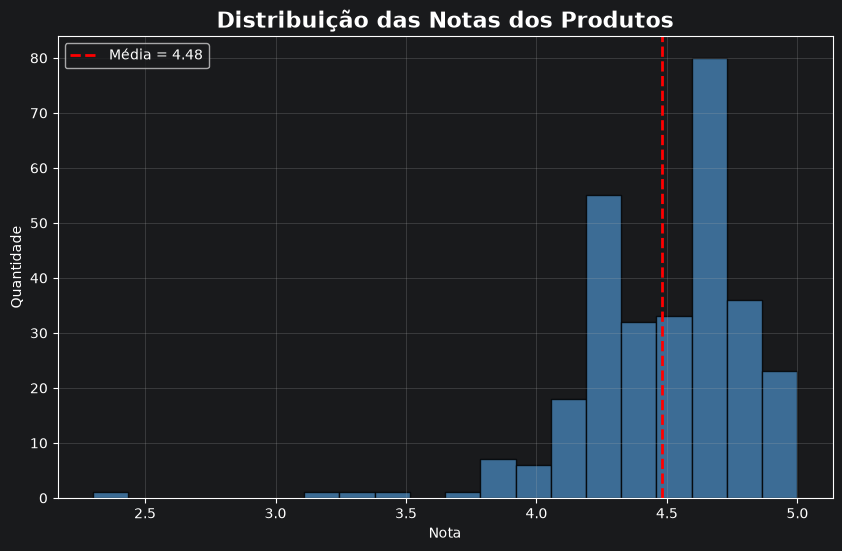

In [3]:
plt.figure(figsize=(10,6))

plt.hist(
    df['Nota'],
    bins=20,
    color='steelblue',
    edgecolor='black',
    alpha=0.8
)

media = df['Nota'].mean()

plt.axvline(
    media,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Média = {media:.2f}'
)

plt.legend()

plt.title('Distribuição das Notas dos Produtos', fontsize=16, fontweight='bold')
plt.xlabel('Nota')
plt.ylabel('Quantidade')
plt.grid(alpha=0.3)

plt.show()

## Análise do Histograma

A média das notas dos produtos é 4,48, indicando elevado nível de satisfação dos consumidores. Observa-se uma concentração das avaliações entre **4,2 e 4,8**, enquanto notas inferiores a 4 aparecem com baixa frequência.

A linha vermelha representa a média das avaliações e reforça visualmente essa concentração em notas altas.

# Gráfico de Dispersão

### Objetivo

Analisar a relação entre o número de avaliações e a nota dos produtos, buscando identificar se produtos mais avaliados tendem a receber melhores avaliações e se existe alguma tendência ou padrão entre essas duas variáveis.

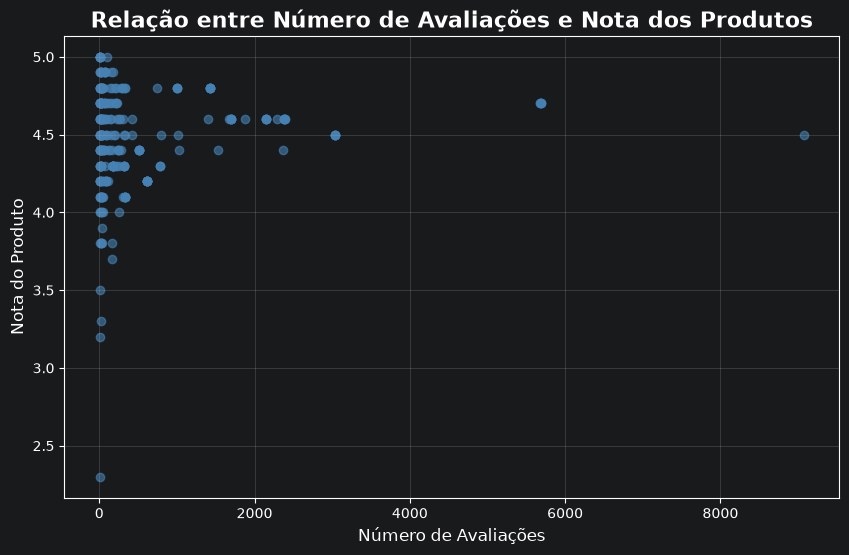

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================
# Carrega os dados
# ==========================

df = pd.read_csv('../data/ecommerce_estatistica.csv')

# ==========================
# Gráfico de Dispersão
# ==========================

plt.figure(figsize=(10, 6))

plt.scatter(
    df['N_Avaliações'],
    df['Nota'],
    color='steelblue',
    alpha=0.6
)

# Título
plt.title(
    'Relação entre Número de Avaliações e Nota dos Produtos',
    fontsize=16,
    fontweight='bold'
)

# Eixos
plt.xlabel('Número de Avaliações', fontsize=12)
plt.ylabel('Nota do Produto', fontsize=12)

# Grade
plt.grid(alpha=0.3)

# Exibe o gráfico
plt.show()

# Análise da Dispersão

O gráfico de dispersão mostra a relação entre o número de avaliações e a nota dos produtos. Observa-se que a maioria dos produtos possui poucas avaliações, enquanto apenas alguns concentram milhares delas. Apesar dessa diferença na quantidade de avaliações, as notas permanecem, em sua maioria, entre 4,0 e 5,0, indicando que produtos populares não necessariamente apresentam avaliações muito superiores aos demais.

# Mapa de Calor

## Objetivo

Visualizar a correlação entre as variáveis numéricas do conjunto de dados, identificando quais atributos possuem relações mais fortes entre si.

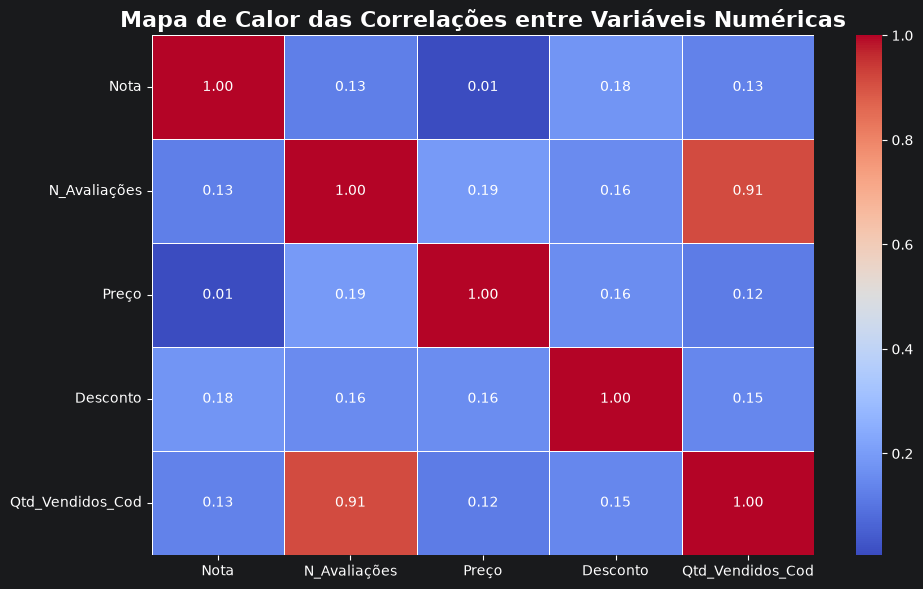

In [9]:
# ==========================
# Mapa de Calor
# ==========================

import seaborn as sns

# Seleciona apenas as principais variáveis numéricas
colunas_correlacao = [
    'Nota',
    'N_Avaliações',
    'Preço',
    'Desconto',
    'Qtd_Vendidos_Cod'
]

# Calcula a matriz de correlação
correlacao = df[colunas_correlacao].corr()

# Define o tamanho da figura
plt.figure(figsize=(10, 6))

# Cria o mapa de calor
sns.heatmap(
    correlacao,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

# Título
plt.title(
    'Mapa de Calor das Correlações entre Variáveis Numéricas',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()

# Exibe o gráfico
plt.show()

# Análise do Mapa de Calor

O mapa de calor evidencia a intensidade da correlação entre as principais variáveis numéricas do conjunto de dados.

A relação mais forte observada foi entre o número de avaliações e a quantidade de produtos vendidos (0,91), indicando que produtos mais vendidos tendem a acumular um maior volume de avaliações.

Por outro lado, as correlações entre preço, nota e desconto apresentaram valores baixos, sugerindo que essas variáveis possuem pouca relação linear entre si. Isso indica que um produto mais caro ou com maior desconto não necessariamente recebe melhores avaliações ou vende mais.

# Gráfico de Barras

## Objetivo

Identificar quais marcas possuem maior quantidade de produtos no conjunto de dados, permitindo visualizar a presença de cada marca no catálogo analisado.

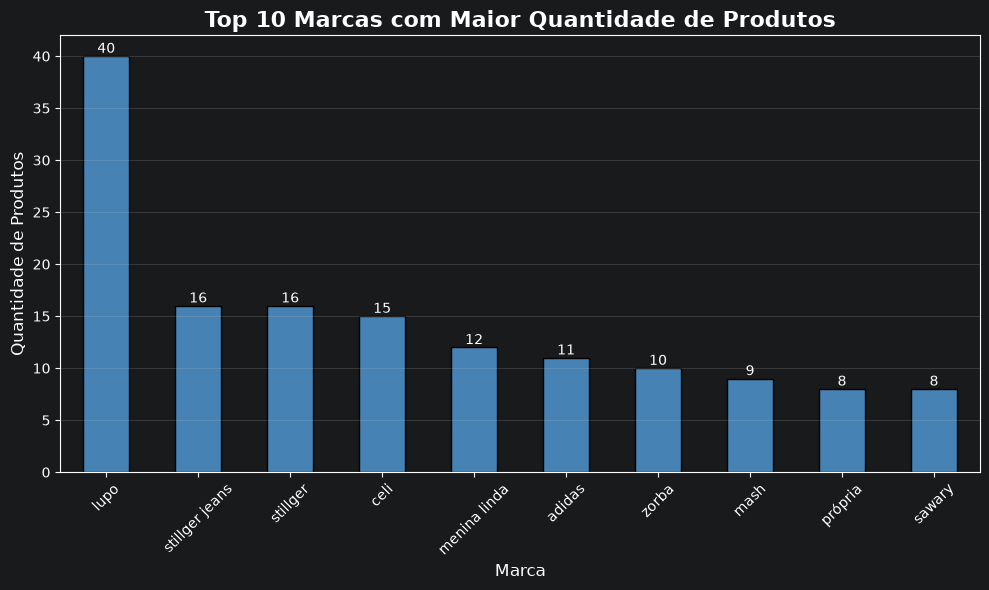

In [9]:
# ==========================
# Gráfico de Barras
# ==========================

top_marcas = df['Marca'].value_counts().head(10)

plt.figure(figsize=(10, 6))

top_marcas.plot(
    kind='bar',
    color='steelblue',
    edgecolor='black'
)
ax = plt.gca()

for barra in ax.patches:
    ax.annotate(
        f'{int(barra.get_height())}',
        (
            barra.get_x() + barra.get_width()/2,
            barra.get_height()
        ),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title('Top 10 Marcas com Maior Quantidade de Produtos', fontsize=16, fontweight='bold')
plt.xlabel('Marca', fontsize=12)
plt.ylabel('Quantidade de Produtos', fontsize=12)

plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.show()

# Análise do Gráfico de Barras

O gráfico evidencia as dez marcas com maior quantidade de produtos presentes no conjunto de dados.

Observa-se que a marca **Lupo** concentra o maior número de produtos, destacando-se em relação às demais. As outras marcas apresentam quantidades menores e relativamente próximas entre si, indicando uma distribuição mais equilibrada após a liderança da Lupo.

Essa visualização permite identificar quais marcas possuem maior representatividade no catálogo analisado e pode auxiliar em decisões relacionadas à estoque, vendas e estratégias comerciais.

# Gráfico de Pizza

## Objetivo

Visualizar a distribuição percentual dos produtos por gênero, identificando a representatividade de cada categoria no conjunto de dados.

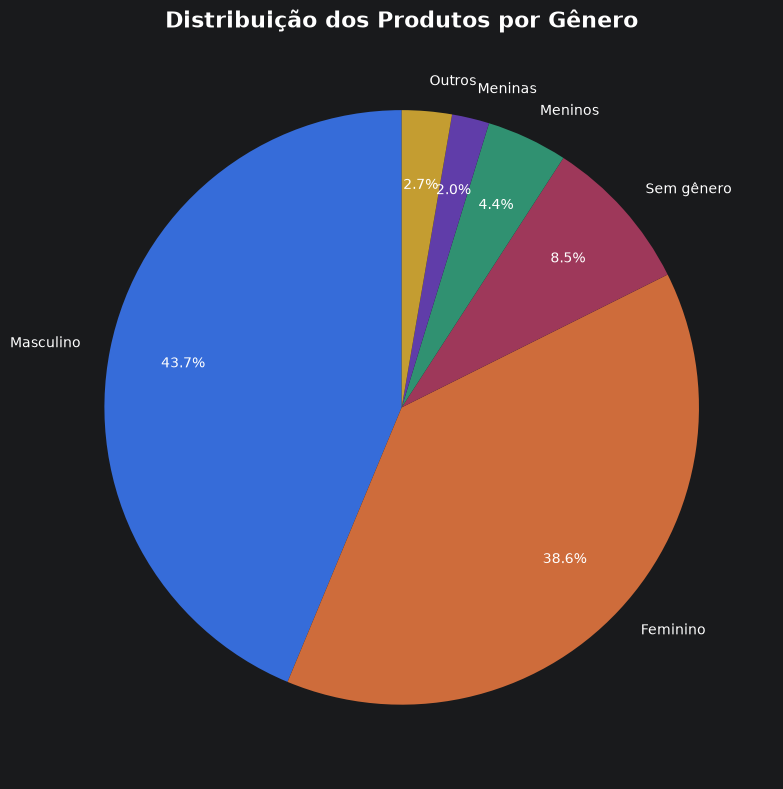

In [23]:
# ==========================
# Gráfico de Pizza
# ==========================

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/ecommerce_estatistica.csv')

# Conta os gêneros
genero = df['Gênero'].value_counts()

# Mantém apenas os 5 maiores
top5 = genero.head(5)

# Soma o restante
outros = genero.iloc[5:].sum()

# Adiciona "Outros"
top5['Outros'] = outros

plt.figure(figsize=(8,8))

plt.pie(
    top5,
    labels=top5.index,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.75
)

plt.title(
    'Distribuição dos Produtos por Gênero',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

# Análise do Gráfico de Pizza

O gráfico de pizza mostra a distribuição percentual dos produtos por gênero no conjunto de dados.

Observa-se que as categorias **Masculino** e **Feminino** concentram a maior parte dos produtos, representando juntas a maior participação do catálogo analisado. A categoria **Sem gênero** aparece em menor proporção, enquanto **Meninos**, **Meninas** e **Outros** possuem participações menores.

Essa visualização permite compreender a composição do catálogo por gênero e identificar quais públicos possuem maior representatividade entre os produtos disponíveis.

# Gráfico de Densidade

## Objetivo

Analisar a concentração das notas dos produtos de forma suavizada, complementando a visualização apresentada no histograma.

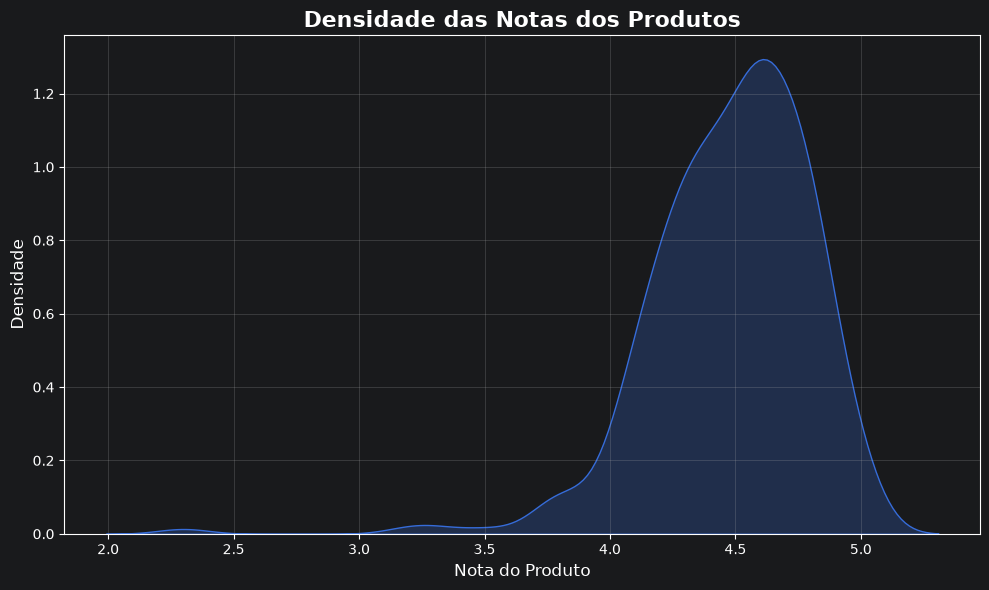

In [24]:
# ==========================
# Gráfico de Densidade
# ==========================

plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=df,
    x='Nota',
    fill=True
)

plt.title('Densidade das Notas dos Produtos', fontsize=16, fontweight='bold')
plt.xlabel('Nota do Produto', fontsize=12)
plt.ylabel('Densidade', fontsize=12)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Análise do Gráfico de Densidade

O gráfico de densidade apresenta uma versão suavizada da distribuição das notas dos produtos, facilitando a identificação das regiões de maior concentração de avaliações.

Observa-se que a maior densidade está entre as notas **4,3 e 4,8**, com pico próximo de **4,6**, indicando que a maior parte dos produtos possui avaliações elevadas. As notas abaixo de **4,0** aparecem com baixa frequência, enquanto avaliações muito baixas são praticamente inexistentes.

Esse comportamento reforça a análise realizada no histograma, evidenciando que os produtos do conjunto de dados apresentam, em geral, alto nível de satisfação por parte dos consumidores.

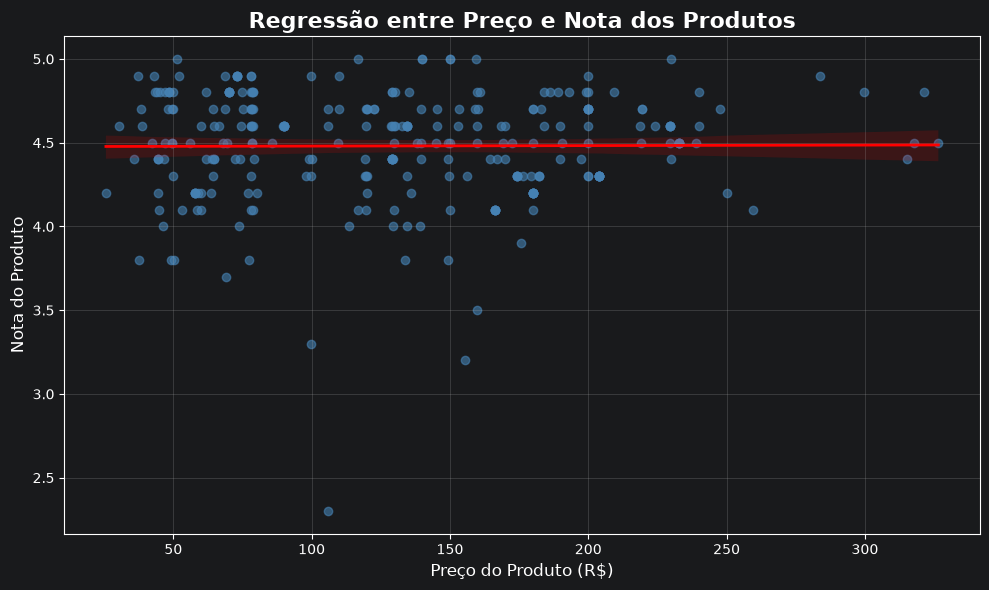

In [8]:
# ==========================
# Gráfico de Regressão
# ==========================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Carrega os dados
df = pd.read_csv('../data/ecommerce_estatistica.csv')

# Define o tamanho da figura
plt.figure(figsize=(10,6))

# Gráfico de regressão
sns.regplot(
    x='Preço',
    y='Nota',
    data=df,
    scatter_kws={
        'alpha':0.6,
        'color':'steelblue'
    },
    line_kws={
        'color':'red',
        'linewidth':2
    }
)

plt.title(
    'Regressão entre Preço e Nota dos Produtos',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Preço do Produto (R$)', fontsize=12)
plt.ylabel('Nota do Produto', fontsize=12)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Análise do Gráfico de Regressão

O gráfico de regressão apresenta a relação entre o preço dos produtos e suas notas médias, permitindo identificar a existência de uma tendência linear entre essas variáveis.

Observa-se que a linha de regressão possui inclinação muito pequena, indicando que o preço exerce pouca influência sobre a nota atribuída pelos consumidores. Produtos mais caros não apresentam, necessariamente, avaliações superiores aos produtos de menor valor.

Assim, conclui-se que a qualidade percebida pelos clientes parece estar relacionada a outros fatores além do preço, como características do produto, marca, material ou experiência de uso.


# Conclusão

A análise exploratória permitiu compreender o comportamento das principais variáveis do conjunto de dados de e-commerce.

As visualizações mostraram que a maioria dos produtos apresenta notas elevadas, indicando boa satisfação dos consumidores. Também foi possível observar uma forte relação entre o número de avaliações e a quantidade de produtos vendidos, enquanto o preço apresentou pouca influência sobre as avaliações recebidas.

Além das visualizações, a utilização de estatísticas descritivas possibilitou complementar a interpretação dos resultados, tornando a análise mais consistente e confiável para apoiar futuras tomadas de decisão.